+ How are in-demand skills trending for DA

Methodology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. plot the monthly skill demand

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:

## Skill count per month for data analysts in Us
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

df_DA_US_exploded = df_DA_US.explode('job_skills')


In [17]:
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


In [5]:
df_DA_US_pivot.loc['total'] = df_DA_US_pivot.sum()
df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


In [10]:
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['total'].sort_values(ascending=False).index]
df_DA_US_pivot

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,google chat,openstack,theano,asp.net core,qt,couchdb,capacitor,codecommit,chainer,msaccess
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,0,0,0,0,0,0,1,1,0,0
2,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
3,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,1,0,0,0,0,0,0,0,0,0
4,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,1,0,0,0,0
5,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,0,0,0,0,1
6,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,1,0,0,1,0,0,0,0,0
7,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
8,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
9,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [18]:
DA_total = df_DA_US.groupby('job_posted_month_no').size()
DA_total

job_posted_month_no
1     8494
2     6124
3     6218
4     6049
5     4993
6     5683
7     5201
8     6634
9     4639
10    5271
11    4531
12    3979
dtype: int64

convert month_no into month_name

In [57]:

# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_perc = df_DA_US_pivot.iloc[:12].div(DA_total/100, axis=0)

# changes month number to month name
df_DA_perc = df_DA_perc.reset_index()
df_DA_perc['job_posted_month'] = df_DA_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_perc = df_DA_perc.set_index('job_posted_month')
df_DA_perc = df_DA_perc.drop(columns='job_posted_month_no')

df_DA_perc


job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,0.459148,0.082411,2.425241,0.247233,0.082411,0.011773,0.000000,0.176595,0.200141,0.000000,...,0.082411,0.105957,0.941841,0.035319,11.396280,0.000000,0.082411,0.000000,0.000000,0.353190
Feb,0.571522,0.000000,3.314827,0.375572,0.065317,0.016329,0.000000,0.228609,0.146963,0.000000,...,0.097975,0.097975,1.502286,0.048988,12.050947,0.048988,0.000000,0.000000,0.000000,0.310255
Mar,0.627211,0.016082,3.522033,0.080412,0.080412,0.096494,0.016082,0.225153,0.176906,0.000000,...,0.112576,0.096494,1.222258,0.080412,11.836603,0.016082,0.016082,0.016082,0.000000,0.257317
Apr,0.462886,0.016532,3.438585,0.132253,0.049595,0.115722,0.049595,0.082658,0.099190,0.000000,...,0.033063,0.066127,1.421723,0.148785,11.489502,0.132253,0.016532,0.000000,0.000000,0.198380
May,0.540757,0.060084,2.884038,0.300421,0.160224,0.180252,0.020028,0.100140,0.260365,0.000000,...,0.020028,0.120168,1.341879,0.020028,11.155618,0.060084,0.000000,0.000000,0.000000,0.180252
Jun,0.686257,0.087982,3.308112,0.158367,0.070385,0.140771,0.052789,0.123174,0.123174,0.000000,...,0.087982,0.035193,1.214147,0.140771,12.686961,0.087982,0.000000,0.000000,0.000000,0.351927
Jul,0.807537,0.038454,3.076331,0.096135,0.057681,0.096135,0.096135,0.115362,0.038454,0.000000,...,0.076908,0.019227,1.134397,0.192271,11.286291,0.000000,0.000000,0.000000,0.019227,0.249952
Aug,0.663250,0.030148,2.818812,0.075369,0.045222,0.150739,0.000000,0.075369,0.045222,0.000000,...,0.045222,0.090443,1.311426,0.060295,11.335544,0.000000,0.000000,0.000000,0.000000,0.391920
Sep,0.474240,0.064669,3.125674,0.237120,0.043113,0.064669,0.086225,0.086225,0.064669,0.000000,...,0.000000,0.086225,1.724510,0.086225,10.303945,0.000000,0.000000,0.000000,0.021556,0.258676


<Axes: xlabel='job_posted_month'>

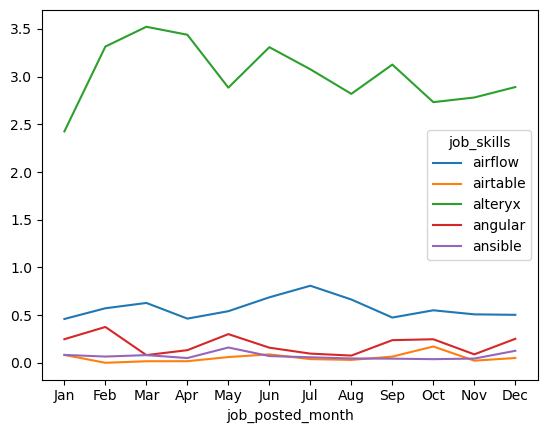

In [ ]:
df_plot = df_DA_perc.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False)

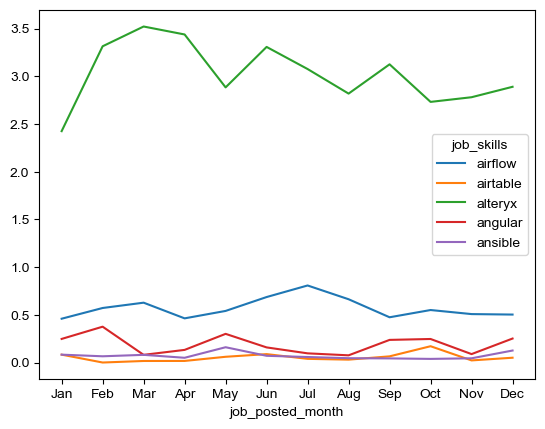

In [ ]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')


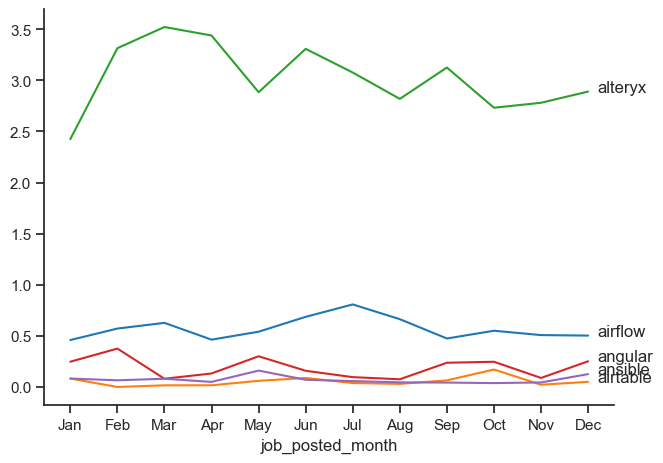

In [ ]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
plt.legend().remove()
plt.tight_layout()
sns.despine() #remove border

for i in range(5): #we have 5 rows
  plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])  #x-coordinate -> month index 11 , y-> df_plot.iloc[-1, i] -1 is last row i is col, val is col name
  

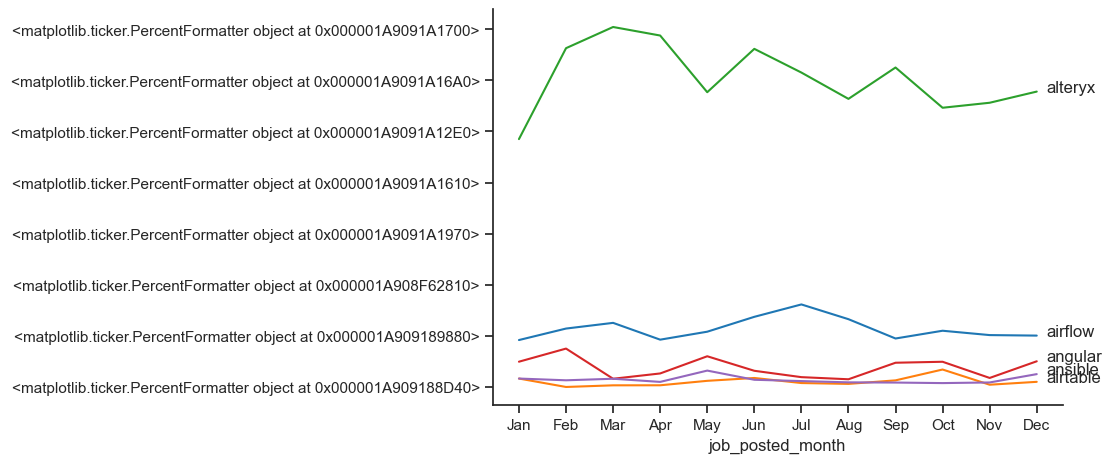

In [68]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
plt.legend().remove()
plt.tight_layout()
sns.despine() #remove border

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter)

for i in range(5): #we have 5 rows
  plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])  #x-coordinate -> month index 11 , y-> df_plot.iloc[-1, i] -1 is last row i is col, val is col name
  